In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

import argosim
from argosim import antenna_utils
from argosim import imaging_utils
from argosim import plot_utils

In [2]:
antenna = antenna_utils.random_antenna_arr(35, E_lim=2000)
baselines = antenna_utils.get_baselines(antenna)
track, f_list = antenna_utils.uv_track_multiband(baselines)

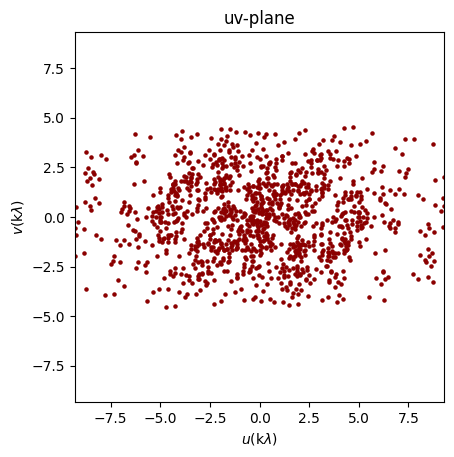

In [3]:
plot_utils.plot_baselines(track)

In [16]:
fov_size = .1 # deg
sky = imaging_utils.uv2sky(jnp.ones((512, 512)))
obs, beam = imaging_utils.simulate_dirty_observation(sky, track, fov_size, sigma=0.5)

/Users/ec270266/Documents/Phd/Argos/repos/argosim/src/argosim/imaging_utils.py:251: UserWarning: Explicitly requested dtype <class 'jax.numpy.complex128'> requested in zeros is not available, and will be truncated to dtype complex64. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  vis = jnp.zeros(uv_px.shape[0], dtype=jnp.complex128)
/Users/ec270266/Documents/Phd/Argos/repos/argosim/src/argosim/imaging_utils.py:202: UserWarning: Explicitly requested dtype <class 'jax.numpy.complex128'> requested in zeros is not available, and will be truncated to dtype complex64. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  grid = jnp.zeros(grid_shape, dtype=jnp.complex128)
/Users/ec270266/anaconda3/envs/argos/lib/python3.12/site-packages/jax

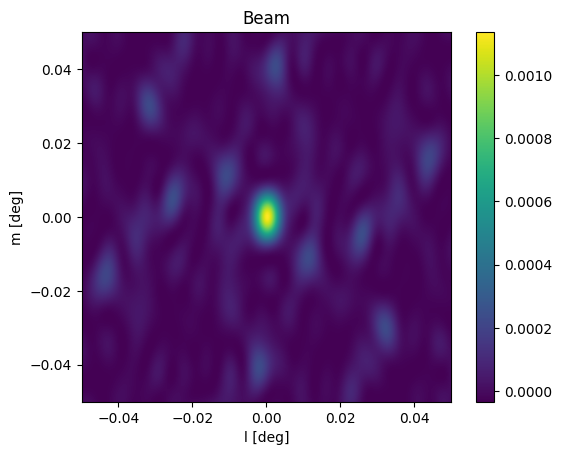

In [17]:
plot_utils.plot_sky(beam, fov_size=(fov_size, fov_size), title="Beam")

In [18]:
from argosim import metrics_utils
import numpy as np

In [19]:
metrics_utils.compute_sll(beam)

-6.705778256074626

In [34]:
from skimage.feature import peak_local_max
from skimage.segmentation import watershed

def _main_lobe_mask_np(beam_np):
    beam_np = np.asarray(beam_np)
    peak_idx = np.unravel_index(np.argmax(beam_np), beam_np.shape)

    # One marker per local maximum -> each lobe gets its own catchment basin
    coords = peak_local_max(beam_np, min_distance=1)
    markers = np.zeros(beam_np.shape, dtype=np.int32)
    for i, c in enumerate(coords, start=1):
        markers[tuple(c)] = i

    labels = watershed(-beam_np, markers=markers)  # flood "downhill" from each peak
    main_label = labels[peak_idx]
    return (labels == main_label).astype(np.float32)

def compute_sll_far(beam):
    # Non-differentiable segmentation step, wrapped for use inside jit/grad
    mask = jax.pure_callback(
        _main_lobe_mask_np,
        jax.ShapeDtypeStruct(beam.shape, jnp.float32),
        beam,
    )
    mask = jax.lax.stop_gradient(mask)

    main_lobe_power = jnp.sum((beam * mask) ** 2)
    side_lobe_power = jnp.sum((beam * (1 - mask)) ** 2)
    sll_db = 10 * jnp.log10(side_lobe_power / main_lobe_power + 1e-12)
    return sll_db

def compute_ssl_peak(beam):
    # Non-differentiable segmentation step, wrapped for use inside jit/grad
    mask = jax.pure_callback(
        _main_lobe_mask_np,
        jax.ShapeDtypeStruct(beam.shape, jnp.float32),
        beam,
    )
    mask = jax.lax.stop_gradient(mask)

    main_lobe_peak_power = jnp.max((beam * mask)**2)
    side_lobe_peak_power = jnp.max((beam * (1 - mask))**2)
    sll_db = 10 * jnp.log10(side_lobe_peak_power / main_lobe_peak_power + 1e-12)
    return sll_db

def plot_sidelobes(beam, fov_size):
    main_lobe_mask = _main_lobe_mask_np(beam)
    fig, ax = plt.subplots(1, 3, figsize=(20, 5))
    plot_utils.plot_sky(main_lobe_mask, fig=fig, ax=ax[0], fov_size=(fov_size, fov_size), title="Main Lobe Mask")
    plot_utils.plot_sky(beam * main_lobe_mask, fig=fig, ax=ax[1], fov_size=(fov_size, fov_size), title="Main Lobe")
    plot_utils.plot_sky(beam * (1 - main_lobe_mask), fig=fig, ax=ax[2], fov_size=(fov_size, fov_size), title="Side Lobes")
    sidelobe_peak_px = np.array(np.unravel_index(np.argmax(beam * (1 - main_lobe_mask)), beam.shape))
    sidelobe_peak_lm = sidelobe_peak_px/beam.shape[0]*fov_size - fov_size/2
    ax[2].scatter(sidelobe_peak_lm[1], sidelobe_peak_lm[0], color='red', s=100, marker='x', label='Side Lobe Peak')
    plt.legend()
    plt.show()

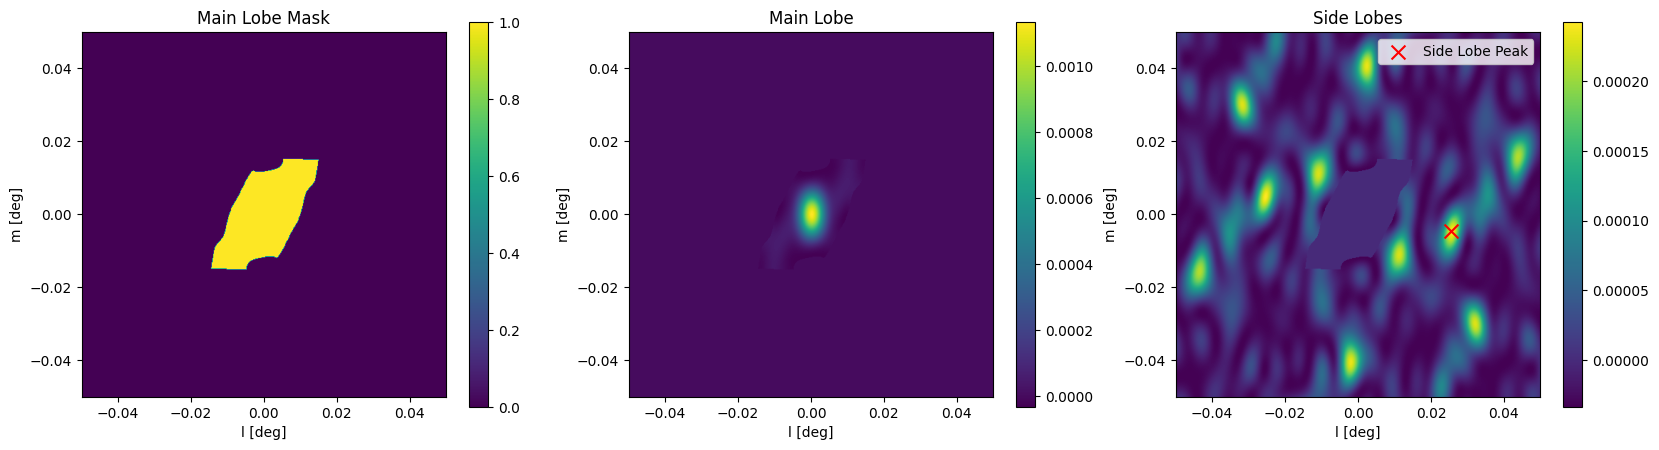

In [35]:
main_lobe_mask = _main_lobe_mask_np(beam)

fig, ax = plt.subplots(1, 3, figsize=(20, 5))
plot_utils.plot_sky(main_lobe_mask, fig=fig, ax=ax[0], fov_size=(fov_size, fov_size), title="Main Lobe Mask")
plot_utils.plot_sky(beam * main_lobe_mask, fig=fig, ax=ax[1], fov_size=(fov_size, fov_size), title="Main Lobe")
plot_utils.plot_sky(beam * (1 - main_lobe_mask), fig=fig, ax=ax[2], fov_size=(fov_size, fov_size), title="Side Lobes")
sidelobe_peak_px = np.array(np.unravel_index(np.argmax(beam * (1 - main_lobe_mask)), beam.shape))
sidelobe_peak_lm = sidelobe_peak_px/beam.shape[0]*fov_size - fov_size/2
ax[2].scatter(sidelobe_peak_lm[1], sidelobe_peak_lm[0], color='red', s=100, marker='x', label='Side Lobe Peak')
plt.legend()
plt.show()

In [36]:
print("SLL (far):", compute_sll_far(beam))
print("SLL (peak):", compute_ssl_peak(beam))

SLL (far): -3.1852531
SLL (peak): -13.411555
